In [5]:
import numpy as np
from pathlib import Path

from find_platforms import (
    hex_grid,
    calculate_cartesian_coords,
    translate_coords,
    makefig,
    get_image,
)


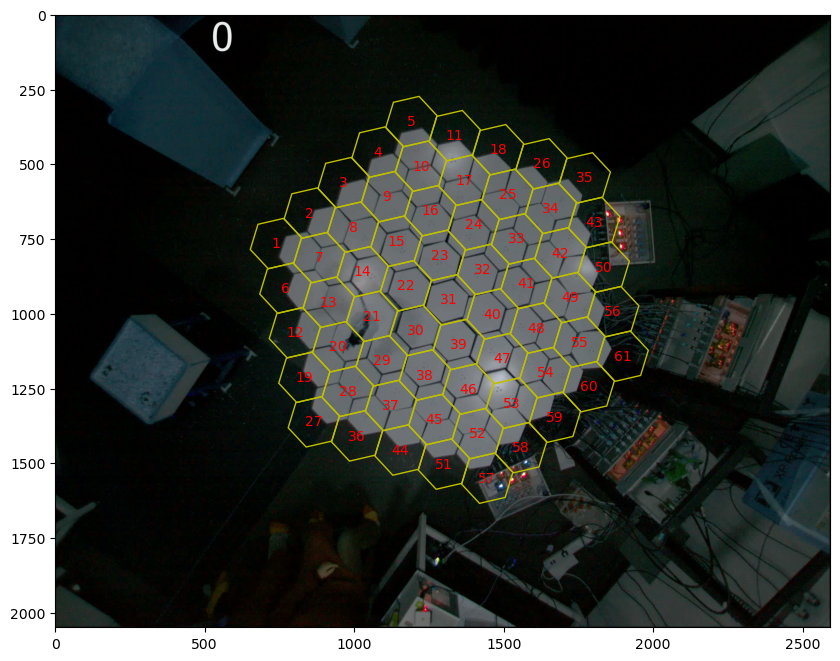

In [ ]:
derivatives_base = r"E:\Honeycomb_task_1g\derivatives\sub-001_id-2H\ses-02_date-12022026\first_run_1302"
derivatives_base = Path(derivatives_base)
method = "video"
tr = 8 # Trial to overlay

"""
Overlay a hexagonal maze grid onto a session image.

tr determines which video you overlay

NOTE: the overlay won't be perfect for all squares due to the angle of the camera, etc. 
Best to optimize the overlay so it works well for the center platform
"""
# Loading rawsession folder
rawsession_folder = Path(
    str(derivatives_base).replace("derivatives", "rawdata")
).parent

# Obtaining image used for overlay
img = get_image(rawsession_folder, method, tr =tr)

# Output folder
output_path = derivatives_base / "analysis" / "maze_overlay" / "maze_overlay.png"
output_path.parent.mkdir(parents=True, exist_ok=True)

# Parameters that control the overlay
radius = 4
hex_side_length = 88 # Length of the side of the hexagon
theta = np.radians(312)  # Rotation angle in radians
desired_x, desired_y = 1318, 953 # center of 31st platform
coord = hex_grid(radius) # coordinates
rotation = 17
#rotation = 50

# Calculate initial Cartesian coordinates
hcoord2, vcoord2 = calculate_cartesian_coords(coord, hex_side_length)
hcoord_translated, vcoord_translated = translate_coords(hcoord2, vcoord2, theta, desired_x, desired_y, num_plats = 61)

# plots figure
good_overlay = makefig(rotation,hex_side_length, hcoord_translated, vcoord_translated, img, output_path, get_user_input = False)




In [ ]:
import json
params_path = derivatives_base / "analysis" / "maze_overlay" / "maze_overlay_params.json"
with open(params_path, 'r') as f:
    params = json.load(f)